🎨 Agricultural Agent Workflow Visualizer


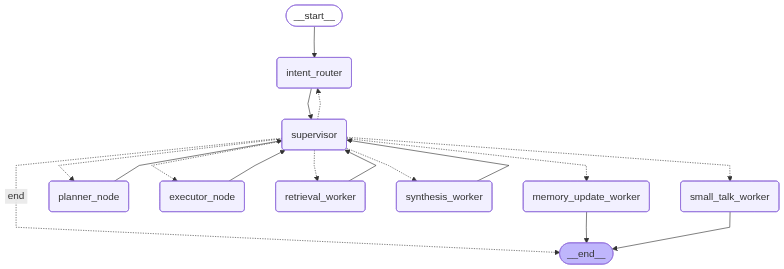

✅ Workflow diagram generated successfully!

📝 Mermaid Diagram Syntax:

graph TD
    START([START]) --> intent_router[🔍 Intent Router]

    intent_router --> supervisor{Supervisor}

    supervisor -->|small_talk| small_talk[💬 Small Talk Worker]
    supervisor -->|sensor/consultation| planner[📋 Planner Node]
    supervisor -->|knowledge| retrieval[📚 Retrieval Worker]

    %% Small Talk Path
    small_talk --> END1([END])

    %% Sequential Execution Path
    planner --> supervisor
    supervisor --> executor[🔧 Executor Node]

    executor -->|Execute sensors| sensor_tool[📊 Sensor Tool]
    executor -->|Execute KB| kb_tool[📖 KB Tool]
    executor -->|All steps done| synthesis[✨ Synthesis Worker]

    sensor_tool --> executor
    kb_tool --> executor
    executor --> supervisor

    %% Knowledge Path
    retrieval --> supervisor
    supervisor --> synthesis

    %% Final Steps
    synthesis --> supervisor
    supervisor --> memory[💾 Memory Update]
    memory --> END2([END])

    %% Styling

In [2]:
"""
Agricultural Agent Workflow Visualization
Generates Mermaid diagram for the SOTA Sequential Tool Execution Agent
"""

from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

# Import your graph builder
# from your_module import build_graph
from src.agent.supervisor_sota_2025 import (
    build_graph, 
)
# Example usage:
def visualize_agent_workflow(mongo_uri: str = "mongodb://localhost:27017", 
                             db_name: str = "agricultural_agent"):
    """
    Visualize the agent workflow graph
    
    Args:
        mongo_uri: MongoDB connection string
        db_name: Database name for memory storage
    """
    # Build the graph
    graph = build_graph(mongo_uri, db_name)
    
    # Generate and display the Mermaid diagram
    try:
        display(
            Image(
                graph.get_graph().draw_mermaid_png(
                    draw_method=MermaidDrawMethod.API,
                )
            )
        )
        print("✅ Workflow diagram generated successfully!")
        
    except Exception as e:
        print(f"❌ Error generating diagram: {e}")
        print("\n📝 Fallback: Mermaid Text Format")
        print(graph.get_graph().draw_mermaid())


def get_mermaid_text(mongo_uri: str = "mongodb://localhost:27017",
                     db_name: str = "agricultural_agent") -> str:
    """
    Get the Mermaid diagram as text (useful for manual rendering)
    
    Returns:
        Mermaid diagram syntax as string
    """
    graph = build_graph(mongo_uri, db_name)
    return graph.get_graph().draw_mermaid()


def save_diagram_to_file(output_path: str = "agent_workflow.png",
                         mongo_uri: str = "mongodb://localhost:27017",
                         db_name: str = "agricultural_agent"):
    """
    Save the workflow diagram to a file
    
    Args:
        output_path: Path to save the PNG file
        mongo_uri: MongoDB connection string
        db_name: Database name
    """
    graph = build_graph(mongo_uri, db_name)
    
    try:
        png_data = graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
        
        with open(output_path, 'wb') as f:
            f.write(png_data)
        
        print(f"✅ Diagram saved to: {output_path}")
        
    except Exception as e:
        print(f"❌ Error saving diagram: {e}")


# ==========================================
# MANUAL MERMAID DIAGRAM (for reference)
# ==========================================

MANUAL_MERMAID = """
graph TD
    START([START]) --> intent_router[🔍 Intent Router]
    
    intent_router --> supervisor{Supervisor}
    
    supervisor -->|small_talk| small_talk[💬 Small Talk Worker]
    supervisor -->|sensor/consultation| planner[📋 Planner Node]
    supervisor -->|knowledge| retrieval[📚 Retrieval Worker]
    
    %% Small Talk Path
    small_talk --> END1([END])
    
    %% Sequential Execution Path
    planner --> supervisor
    supervisor --> executor[🔧 Executor Node]
    
    executor -->|Execute sensors| sensor_tool[📊 Sensor Tool]
    executor -->|Execute KB| kb_tool[📖 KB Tool]
    executor -->|All steps done| synthesis[✨ Synthesis Worker]
    
    sensor_tool --> executor
    kb_tool --> executor
    executor --> supervisor
    
    %% Knowledge Path
    retrieval --> supervisor
    supervisor --> synthesis
    
    %% Final Steps
    synthesis --> supervisor
    supervisor --> memory[💾 Memory Update]
    memory --> END2([END])
    
    %% Styling
    classDef entryClass fill:#e1f5e1,stroke:#4caf50,stroke-width:3px
    classDef workerClass fill:#e3f2fd,stroke:#2196f3,stroke-width:2px
    classDef toolClass fill:#fff3e0,stroke:#ff9800,stroke-width:2px
    classDef supervisorClass fill:#f3e5f5,stroke:#9c27b0,stroke-width:3px
    classDef endClass fill:#ffebee,stroke:#f44336,stroke-width:2px
    
    class START,intent_router entryClass
    class small_talk,planner,retrieval,synthesis,memory workerClass
    class executor,sensor_tool,kb_tool toolClass
    class supervisor supervisorClass
    class END1,END2 endClass
"""


if __name__ == "__main__":
    print("🎨 Agricultural Agent Workflow Visualizer")
    print("=" * 50)
    
    # Option 1: Direct visualization (in Jupyter)
    visualize_agent_workflow()
    
    # Option 2: Get Mermaid text for manual rendering
    print("\n📝 Mermaid Diagram Syntax:")
    print(MANUAL_MERMAID)
    
    # Option 3: Save to file
    save_diagram_to_file("agent_workflow.png")
    
    print("\n" + "=" * 50)
    print("📚 Usage Instructions:")
    print("1. In Jupyter: Run visualize_agent_workflow()")
    print("2. Manual render: Copy MANUAL_MERMAID to mermaid.live")
    print("3. Save to file: Run save_diagram_to_file('output.png')")